In [ ]:
import polars as pl
import pandas as pd
from pathlib import Path
from datetime import date, timedelta
import time
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
IN_DIR = Path("D:\\gdelt_data\\2016_mentions_output")
MENTION_COLS = ["GlobalEventID", "EventTimeDate", "MentionTimeDate", "MentionType", "MentionSourceName", "MentionIdentifier", "SentenceID", "Actor1CharOffset", "Actor2CharOffset", "ActionCharOffset", "InRawText", "Confidence", "MentionDocLen", "MentionDocTone", "MentionDocTranslationInfo", "Extras"]
EVENT_COLS = ["GlobalEventID", "Day", "MonthYear", "Year", "FractionDate", "Actor1Code", "Actor1Name", "Actor1CountryCode", "Actor1KnownGroupCode", "Actor1EthnicCode", "Actor1Religion1Code", 
                "Actor1Religion2Code", "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code", "Actor2Code", "Actor2Name", "Actor2CountryCode", "Actor2KnownGroupCode", "Actor2EthnicCode", 
                "Actor2Religion1Code", "Actor2Religion2Code", "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code", "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode", 
                "QuadClass", "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "AvgTone", 
                "Actor1Geo_Type", "Actor1Geo_FullName", "Actor1Geo_CountryCode", "Actor1Geo_ADM1Code", "Actor1Geo_Lat", "Actor1Geo_Long", "Actor1Geo_FeatureID", 
                "Actor2Geo_Type", "Actor2Geo_FullName", "Actor2Geo_CountryCode", "Actor2Geo_ADM1Code", "Actor2Geo_Lat", "Actor2Geo_Long", "Actor2Geo_FeatureID", 
                "ActionGeo_Type", "ActionGeo_FullName", "ActionGeo_CountryCode", "ActionGeo_ADM1Code", "ActionGeo_Lat", "ActionGeo_Long", "ActionGeo_FeatureID", 
                "DATEADDED", "SOURCEURL"]

In [43]:
def merge_events_and_mentions(day, cols):
    year = day[:4]
    in_dir = Path(f"D:\\gdelt_data\\{year}_mentions_output")
    # import 20160101.mentions.parquet
    daily_mentions_parquet = pl.read_parquet(in_dir / f"{day}.mentions.parquet")
    # import 20160101.export.CSV.zip
    daily_events = pd.read_csv(f"D:\\gdelt_data\\{year}_events\\{day}.export.CSV.zip", compression="zip", header=None, sep="\t", low_memory=False)
    daily_events_pl = pl.from_pandas(daily_events)

    daily_events_pl.columns = EVENT_COLS
    daily_mentions_parquet.columns = MENTION_COLS

    merged = daily_mentions_parquet.join(
        daily_events_pl,
        left_on="GlobalEventID",
        right_on="GlobalEventID",
        how="inner"
    )
    if len(cols) == 1:
        print(merged[cols[0]].value_counts())

    out_dir = Path(f"D:\\gdelt_data\\{year}_merged")
    out_dir.mkdir(parents=True, exist_ok=True)

    merged = merged.select(cols)
    merged.write_csv(out_dir / f"merged{day}.csv")

    return merged

In [73]:
start = date(2016, 1, 1)
end = date(2025, 12, 31)
time_interval = 150

summary = defaultdict(int)
current = start

while current <= end:
    time.sleep(0.2)
    datestr = current.strftime("%Y%m%d")

    merged = merge_events_and_mentions(datestr, cols=["Confidence", "InRawText", "IsRootEvent"])
    
    counts = (
        merged
        .group_by(["Confidence", "InRawText", "IsRootEvent"])
        .len()
    )

    for row in counts.iter_rows(named=True):
        key = (
            row["Confidence"],
            row["InRawText"],
            row["IsRootEvent"]
        )
        summary[key] += row["len"]
    #print(merged)
    print(f"Processed {datestr}")
    current += timedelta(days=time_interval)

Processed 20160101
Processed 20160530
Processed 20161027
Processed 20170326
Processed 20170823
Processed 20180120
Processed 20180619
Processed 20181116
Processed 20190415
Processed 20190912
Processed 20200209
Processed 20200708
Processed 20201205
Processed 20210504
Processed 20211001
Processed 20220228
Processed 20220728
Processed 20221225
Processed 20230524
Processed 20231021
Processed 20240319
Processed 20240816
Processed 20250113
Processed 20250612
Processed 20251109


## Counts of the Event Codes

In [ ]:
summary_df = pd.DataFrame(
    [
        {
            "Confidence": k[0],
            "InRawText": k[1],
            "IsRootEvent": k[2],
            "Count": v
        }
        for k, v in summary.items()
    ]
).sort_values("Count", ascending=False)
#summary_df.to_csv("summary_of_cameo_codes.csv", index=False)
#summary_df.to_csv("summary_of_geo_types.csv", index=False)
#summary_df = pd.read_csv("summary_of_cameo_codes.csv")
#summary_df = pd.read_csv("summary_of_geo_types.csv")

print(summary_df)
#print(summary_df.groupby("EventRootCode")["Count"].sum().sort_values())

    Confidence  InRawText  IsRootEvent    Count
0           20          0            1  1532957
1          100          1            1  1294422
2           20          0            0   932257
3           40          0            1   849527
4           10          0            1   669359
5           10          0            0   570710
6           60          1            1   549070
7           50          1            1   474225
8           30          1            1   364474
9          100          1            0   343596
10          80          1            1   320611
11          40          0            0   311113
12          60          1            0   284214
13          30          1            0   197587
14          50          1            0   170412
15          40          1            1   159380
16          80          1            0   155390
17          20          1            1   153832
18          70          1            1   102959
19          60          0            1  

In [76]:
summary_df[summary_df["InRawText"] == 1]

,Confidence,InRawText,IsRootEvent,Count
1,100,1,1,1294422
6,60,1,1,549070
7,50,1,1,474225
8,30,1,1,364474
9,100,1,0,343596
10,80,1,1,320611
12,60,1,0,284214
13,30,1,0,197587
14,50,1,0,170412
15,40,1,1,159380


Most Common CAMEO Event Root Codes:
- 4: Consult
- 1: Make Public Statement
- 2: Appeal
- 5: Engage in Diplomatic Cooperation
- 19: Fight
- 11: Disapprove

In [ ]:
explore_df = pd.read_csv("D:\\gdelt_data\\2016_merged\\merged20160101.csv", low_memory=False)

In [8]:
explore_df.columns

Index(['GlobalEventID', 'EventTimeDate', 'MentionTimeDate', 'MentionType',
       'MentionSourceName', 'MentionIdentifier', 'SentenceID',
       'Actor1CharOffset', 'Actor2CharOffset', 'ActionCharOffset', 'InRawText',
       'Confidence', 'MentionDocLen', 'MentionDocTone',
       'MentionDocTranslationInfo', 'Extras', 'Day', 'MonthYear', 'Year',
       'FractionDate', 'Actor1Code', 'Actor1Name', 'Actor1CountryCode',
       'Actor1KnownGroupCode', 'Actor1EthnicCode', 'Actor1Religion1Code',
       'Actor1Religion2Code', 'Actor1Type1Code', 'Actor1Type2Code',
       'Actor1Type3Code', 'Actor2Code', 'Actor2Name', 'Actor2CountryCode',
       'Actor2KnownGroupCode', 'Actor2EthnicCode', 'Actor2Religion1Code',
       'Actor2Religion2Code', 'Actor2Type1Code', 'Actor2Type2Code',
       'Actor2Type3Code', 'IsRootEvent', 'EventCode', 'EventBaseCode',
       'EventRootCode', 'QuadClass', 'GoldsteinScale', 'NumMentions',
       'NumSources', 'NumArticles', 'AvgTone', 'Actor1Geo_Type',
       'Actor1G

In [12]:
explore_df.dtypes
#print all columns and their data types
for col in explore_df.columns:
    format = explore_df[col].dtype
    print(f"{col}: {format}")
    if format == "int64":
        print(f"Min: {explore_df[col].min()}, Max: {explore_df[col].max()}")
    if format == "float64":
        print(f"Min: {explore_df[col].min()}, Max: {explore_df[col].max()}")
    #if format == "str": #print most common values and their counts
    #    print(explore_df[col].value_counts().head(10))

GlobalEventID: int64
Min: 498554164, Max: 498717373
EventTimeDate: int64
Min: 20160101000000, Max: 20160101234500
MentionTimeDate: int64
Min: 20160101000000, Max: 20160101234500
MentionType: int64
Min: 1, Max: 2
MentionSourceName: str
MentionIdentifier: str
SentenceID: int64
Min: 1, Max: 258
Actor1CharOffset: int64
Min: -1, Max: 70895
Actor2CharOffset: int64
Min: -1, Max: 70895
ActionCharOffset: int64
Min: -1, Max: 70869
InRawText: int64
Min: 0, Max: 1
Confidence: int64
Min: 10, Max: 100
MentionDocLen: int64
Min: 235, Max: 91203
MentionDocTone: float64
Min: -25.78125, Max: 15.9509202453988
MentionDocTranslationInfo: float64
Min: nan, Max: nan
Extras: float64
Min: nan, Max: nan
Day: int64
Min: 20060103, Max: 20160101
MonthYear: int64
Min: 200601, Max: 201601
Year: int64
Min: 2006, Max: 2016
FractionDate: float64
Min: 2006.0082, Max: 2016.0027
Actor1Code: str
Actor1Name: str
Actor1CountryCode: str
Actor1KnownGroupCode: str
Actor1EthnicCode: str
Actor1Religion1Code: str
Actor1Religion2Cod

In [13]:
explore_df["MentionType"]

0         1
1         1
2         1
3         1
4         1
         ..
329529    1
329530    1
329531    1
329532    1
329533    1
Name: MentionType, Length: 329534, dtype: int64

In [10]:
#explore_df.memory_usage(deep=True) / 1000000
# print memory usage of each column in megabytes
#for col in explore_df.columns:
#    print(f"{col}: {explore_df[col].memory_usage(deep=True) / 1000000:.2f} MB")

In [33]:
explore_df.head().iloc[:, :20]

,GlobalEventID,EventTimeDate,MentionTimeDate,MentionType,MentionSourceName,MentionIdentifier,SentenceID,Actor1CharOffset,Actor2CharOffset,ActionCharOffset,InRawText,Confidence,MentionDocLen,MentionDocTone,MentionDocTranslationInfo,Extras,Day,MonthYear,Year,FractionDate
0,498554164,20160101000000,20160101000000,1,digitaljournal.com,http://www.digitaljournal.com/pr/2789583,2,1138,-1,1176,1,30,1880,1.718213,NaN,NaN,20060103,200601,2006,2006.0082
1,498554165,20160101000000,20160101000000,1,digitaljournal.com,http://www.digitaljournal.com/pr/2789583,2,1138,-1,1176,1,30,1880,1.718213,NaN,NaN,20060103,200601,2006,2006.0082
2,498554166,20160101000000,20160101000000,1,digitaljournal.com,http://www.digitaljournal.com/pr/2789583,2,1138,-1,1219,1,60,1880,1.718213,NaN,NaN,20060103,200601,2006,2006.0082
3,498554167,20160101000000,20160101000000,1,digitaljournal.com,http://www.digitaljournal.com/pr/2789583,2,1138,1186,1176,0,30,1880,1.718213,NaN,NaN,20060103,200601,2006,2006.0082
4,498554168,20160101000000,20160101000000,1,digitaljournal.com,http://www.digitaljournal.com/pr/2789583,2,1138,1202,1176,0,10,1880,1.718213,NaN,NaN,20060103,200601,2006,2006.0082


In [34]:
explore_df.head().iloc[:, 20:40]

,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,Actor1Religion1Code,Actor1Religion2Code,Actor1Type1Code,Actor1Type2Code,Actor1Type3Code,Actor2Code,Actor2Name,Actor2CountryCode,Actor2KnownGroupCode,Actor2EthnicCode,Actor2Religion1Code,Actor2Religion2Code,Actor2Type1Code,Actor2Type2Code,Actor2Type3Code
0,BUS,CORPORATION,NaN,NaN,NaN,NaN,NaN,BUS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BUS,CORPORATION,NaN,NaN,NaN,NaN,NaN,BUS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BUS,CORPORATION,NaN,NaN,NaN,NaN,NaN,BUS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BUS,CORPORATION,NaN,NaN,NaN,NaN,NaN,BUS,NaN,NaN,CAN,CANADA,CAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BUS,CORPORATION,NaN,NaN,NaN,NaN,NaN,BUS,NaN,NaN,CAN,CANADA,CAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
explore_df.head().iloc[:, 40:60]

,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,Actor1Geo_Type,Actor1Geo_FullName,Actor1Geo_CountryCode,Actor1Geo_ADM1Code,Actor1Geo_Lat,Actor1Geo_Long,Actor1Geo_FeatureID,Actor2Geo_Type,Actor2Geo_FullName,Actor2Geo_CountryCode
0,1,51,51,5,1,3.4,6,2,6,1.724158,4,"American Creek, British Columbia, Canada",CA,CA02,49.05,-116.0,-560119,0,NaN,NaN
1,1,51,51,5,1,3.4,6,2,6,1.724158,5,"Province Of British Columbia, British Columbia...",CA,CA02,55.00,-125.0,-561661,0,NaN,NaN
2,1,70,70,7,2,7.0,12,2,12,1.724158,4,"American Creek, British Columbia, Canada",CA,CA02,49.05,-116.0,-560119,0,NaN,NaN
3,1,51,51,5,1,3.4,6,2,6,1.724158,4,"American Creek, British Columbia, Canada",CA,CA02,49.05,-116.0,-560119,4,"American Creek, British Columbia, Canada",CA
4,1,51,51,5,1,3.4,2,2,2,1.724158,5,"Province Of British Columbia, British Columbia...",CA,CA02,55.00,-125.0,-561661,5,"Province Of British Columbia, British Columbia...",CA


In [36]:
explore_df.head().iloc[:, 60:80]

,Actor2Geo_ADM1Code,Actor2Geo_Lat,Actor2Geo_Long,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,binary
0,NaN,NaN,NaN,NaN,4,"American Creek, British Columbia, Canada",CA,CA02,49.05,-116.0,-560119,20160101,http://www.digitaljournal.com/pr/2789583,True
1,NaN,NaN,NaN,NaN,5,"Province Of British Columbia, British Columbia...",CA,CA02,55.00,-125.0,-561661,20160101,http://www.digitaljournal.com/pr/2789583,True
2,NaN,NaN,NaN,NaN,4,"American Creek, British Columbia, Canada",CA,CA02,49.05,-116.0,-560119,20160101,http://www.digitaljournal.com/pr/2789583,True
3,CA02,49.05,-116.0,-560119,4,"American Creek, British Columbia, Canada",CA,CA02,49.05,-116.0,-560119,20160101,http://www.digitaljournal.com/pr/2789583,True
4,CA02,55.00,-125.0,-561661,5,"Province Of British Columbia, British Columbia...",CA,CA02,55.00,-125.0,-561661,20160101,http://www.digitaljournal.com/pr/2789583,True


In [14]:
# proportion of Nans in each column and save to csv:
#with open("nan_proportions.csv", "w") as f:
#    f.write("Column,Proportion_NaN\n")
#    for col in explore_df.columns:
#        prop_nan = explore_df[col].isna().mean()
#        print(f"{col}: {prop_nan:.2%} NaN")
#        f.write(f"{col},{prop_nan:.2%}\n")

In [40]:
nan_props = pd.DataFrame({
    "Column": explore_df.columns,
    "NaN_Proportion": [explore_df[c].isna().mean() for c in explore_df.columns]
})

print(nan_props.to_clipboard(index=False))

None


Correlation plots

In [17]:
numerical_vars = ["EventTimeDate", "MentionTimeDate", "SentenceID", "Actor1CharOffset", "Actor2CharOffset", "ActionCharOffset", "Confidence", "MentionDocLen", "MentionDocTone", "FractionDate", "GoldsteinScale", 
                  "NumMentions", "NumSources", "NumArticles", "AvgTone", "Actor1Geo_Lat", "Actor1Geo_Long", "Actor2Geo_Lat", "Actor2Geo_Long", "ActionGeo_Lat", "ActionGeo_Long"]
numerical_df = explore_df[numerical_vars]
numerical_df = numerical_df.dropna()
numerical_df

,EventTimeDate,MentionTimeDate,SentenceID,Actor1CharOffset,Actor2CharOffset,ActionCharOffset,Confidence,MentionDocLen,MentionDocTone,FractionDate,...,NumMentions,NumSources,NumArticles,AvgTone,Actor1Geo_Lat,Actor1Geo_Long,Actor2Geo_Lat,Actor2Geo_Long,ActionGeo_Lat,ActionGeo_Long
3,20160101000000,20160101000000,2,1138,1186,1176,30,1880,1.718213,2006.0082,...,6,2,6,1.724158,49.0500,-116.0000,49.0500,-116.0000,49.0500,-116.0000
4,20160101000000,20160101000000,2,1138,1202,1176,10,1880,1.718213,2006.0082,...,2,2,2,1.724158,55.0000,-125.0000,55.0000,-125.0000,55.0000,-125.0000
5,20160101000000,20160101000000,2,1138,1186,1213,40,1880,1.718213,2006.0082,...,8,2,8,1.724158,49.0500,-116.0000,49.0500,-116.0000,49.0500,-116.0000
8,20160101000000,20160101000000,18,5695,5725,-1,20,7300,-0.649351,2015.0027,...,4,2,4,-0.649351,-20.0000,134.0000,-20.0000,134.0000,-20.0000,134.0000
9,20160101000000,20160101000000,18,5695,5725,5751,20,7300,-0.649351,2015.0027,...,4,2,4,-0.649351,-20.0000,134.0000,-20.0000,134.0000,-20.0000,134.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329529,20160101003000,20160101234500,42,8909,8994,8971,30,18578,-4.736842,2016.0027,...,9,3,9,-4.805918,48.1500,11.5833,27.7481,116.2740,48.1500,11.5833
329530,20160101234500,20160101234500,15,4792,4841,4847,10,5441,-2.051836,2016.0027,...,1,1,1,-2.051836,36.2028,37.1586,36.2028,37.1586,36.2028,37.1586
329531,20160101234500,20160101234500,15,4792,4858,4864,10,5441,-2.051836,2016.0027,...,1,1,1,-2.051836,35.0000,105.0000,36.2028,37.1586,36.2028,37.1586
329532,20160101210000,20160101234500,11,2271,2293,2244,10,2756,-10.042735,2016.0027,...,77,77,77,-10.090378,40.7502,-119.6260,40.7502,-119.6260,40.7502,-119.6260


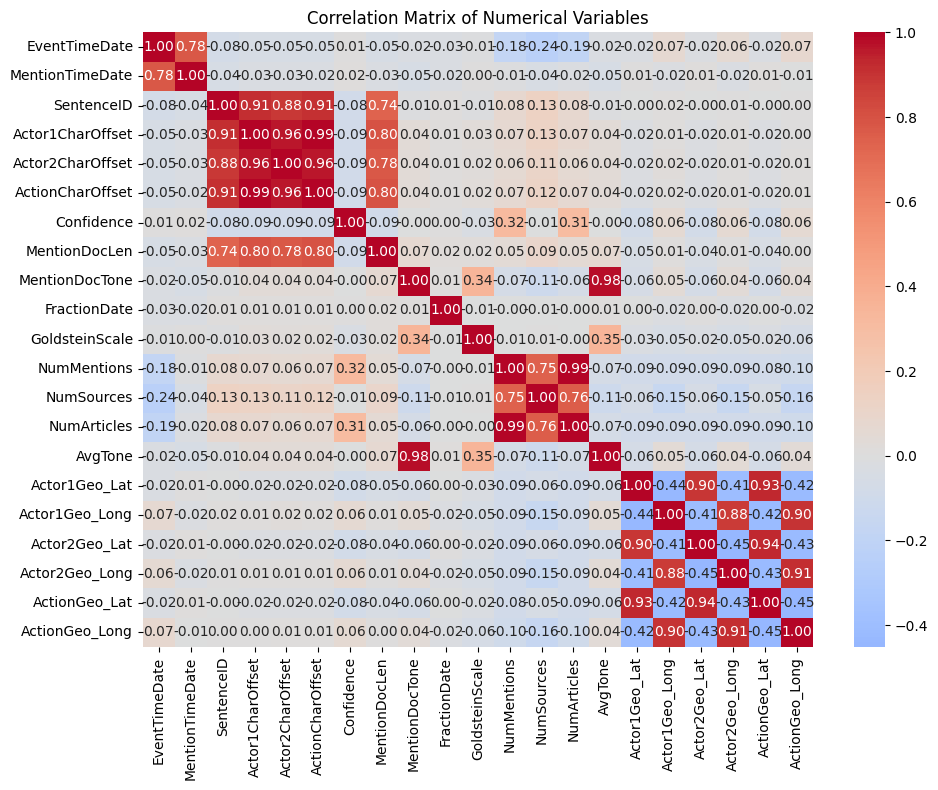

In [21]:
# sns correlation plot of dataframe
corr = numerical_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,      # show correlation values
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

Takeaways:
- SentenceID, ActionCharOffset, Actor1CharOffset, Actor2CharOffset, and MentionDocLen measure similar things
- NumMentions and NumArticles correlate almost perfectly
- AvgTone and MentionDocTone correlate almost perfectly
- Geographic Information about Actor1, Actor2 and Action are all similar

## Main Loop for Gathering Data

In [ ]:
import utils
from utils import merge_events_and_mentions
import inspect
import importlib

ModuleNotFoundError: No module named 'Path'

In [ ]:
# verify it is correct .parquet file

#with open(r"D:\gdelt_data\2016_merged\merged20160101.csv", "rb") as f:
#    print(f.read(4))

NameError: name 'Path' is not defined

In [ ]:
start = date(2021, 1, 1)
end = date(2025, 5, 31)

current = start
while current <= end:

merged.write_parquet(
    rf"D:\gdelt_data\{year}_merged\merged{day}.parquet"
)

In [92]:
importlib.reload(utils)

start = date(2021, 1, 1)
end = date(2025, 5, 31)
time_interval = 1

cols_to_keep = ["GlobalEventID", "EventTimeDate", "MentionTimeDate", "MentionSourceName", "SentenceID", "Actor1CharOffset", "Actor2CharOffset", "ActionCharOffset", "InRawText", "Confidence", 
                "MentionDocLen", "MentionDocTone", "Day", "FractionDate", "Actor1Code", "Actor2Code", "IsRootEvent", "EventRootCode", 
                "QuadClass", "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "Actor1Geo_CountryCode", "Actor1Geo_ADM1Code", "Actor1Geo_Lat", "Actor1Geo_Long", "Actor2Geo_CountryCode", "Actor2Geo_ADM1Code",
                "Actor2Geo_Lat", "Actor2Geo_Long", "ActionGeo_CountryCode", "ActionGeo_ADM1Code", "ActionGeo_Lat", "ActionGeo_Long"]

start_time = time.time()

summary = defaultdict(int)
current = start

while current <= end:
    time.sleep(0.2)
    datestr = current.strftime("%Y%m%d")

    utils.merge_events_and_mentions(datestr, cols_to_keep=cols_to_keep, write="parquet", drop_missing=False)
    #print(f"Saved {100 * len(merged)/prev_len} % of the rows")
    print(f"Processed {datestr}")
    current += timedelta(days=time_interval)

print(f"Ran in {time.time() - start_time} seconds")

#With drop_missing = True: 282 seconds
#With drop_missing = False: 269 seconds -> without

Processed 20210101
Processed 20210102
Processed 20210103
Processed 20210104
Processed 20210105
Processed 20210106
Processed 20210107
Processed 20210108
Processed 20210109
Processed 20210110
Processed 20210111
Processed 20210112
Processed 20210113
Processed 20210114
Processed 20210115
Processed 20210116
Processed 20210117
Processed 20210118
Processed 20210119
Processed 20210120
Processed 20210121
Processed 20210122
Processed 20210123
Processed 20210124
Processed 20210125
Processed 20210126
Processed 20210127
Processed 20210128
Processed 20210129
Processed 20210130
Processed 20210131
Processed 20210201
Processed 20210202
Processed 20210203
Processed 20210204
Processed 20210205
Processed 20210206
Processed 20210207
Processed 20210208
Processed 20210209
Processed 20210210
Processed 20210211
Processed 20210212
Processed 20210213
Processed 20210214
Processed 20210215
Processed 20210216
Processed 20210217
Processed 20210218
Processed 20210219
Processed 20210220
Processed 20210221
Processed 20